<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Task 4</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
    <b>Instruction:</b> Train a linear regression model in PyTorch using a regression dataset. Use the following parameters.
</p>

<ul>
    <li>Criterion: MSE Loss</li>
    <li>Fully Connected Layers x 2</li>
    <li>Batch Size: 8</li>
    <li>Optimizer: SGD</li>
    <li>Epoch: 1000</li>
</ul>
</div>

# Laboratory Task 4 – 01 Understanding Deep Learning

### 1. Import Libraries
This cell imports essential libraries like `torch` for tensor operations, `torch.nn` for neural network components, `torch.optim` for optimizers, `TensorDataset` and `DataLoader` for data handling, and `matplotlib.pyplot` for plotting.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

### 2. Define Dataset
This cell defines our custom input features `X` and target values `y` as PyTorch tensors. This is a small, static dataset for our regression problem.

In [12]:
X = torch.tensor([
    [30.0, 0.20, 0.10],
    [35.0, 0.25, 0.12],
    [40.0, 0.30, 0.15],
    [45.0, 0.35, 0.18],
    [50.0, 0.40, 0.20],
    [55.0, 0.45, 0.22],
    [60.0, 0.50, 0.25],
    [65.0, 0.55, 0.28]
], dtype=torch.float32)

y = torch.tensor([
    [10.0],
    [12.0],
    [14.0],
    [16.0],
    [18.0],
    [20.0],
    [22.0],
    [24.0]
], dtype=torch.float32)

### 3. Create DataLoader
Here, `X` and `y` are combined into a `TensorDataset`, and then a `DataLoader` is created with a `batch_size` of 8 and `shuffle=True`. This prepares the data for mini-batch training.

In [13]:
dataset = TensorDataset(X, y)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

### 4. Define Regression Model
This cell defines the `RegressionModel` using `nn.Module`. It consists of two fully connected layers: `fc1` (3 input features to 16 hidden units with ReLU activation) and `fc2` (16 hidden units to 1 output feature), as requested.

In [14]:
class RegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### 5. Instantiate Model
This cell creates an instance of our `RegressionModel` and prints its architecture to verify the layer structure.

In [15]:
model = RegressionModel()

print(model)

RegressionModel(
  (fc1): Linear(in_features=3, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


### 6. Define Loss Function and Optimizer
We set up `nn.MSELoss()` as the criterion for our regression task and `optim.SGD` with a learning rate of `0.001` as the optimizer to update model weights.

In [16]:
criterion = nn.MSELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001
)

### 7. Training Loop
This cell contains the main training loop. The model is trained for 1000 epochs, processing data in batches. For each batch, it performs a forward pass, calculates the MSE loss, backpropagates gradients, and updates model parameters using the SGD optimizer. Loss values are recorded and printed periodically.

In [17]:
epochs = 1000

losses = []

for epoch in range(epochs):

    for X_batch, y_batch in dataloader:

        # Forward pass
        predictions = model(X_batch)

        # Calculate MSE loss
        loss = criterion(predictions, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [100/1000], Loss: 221.8110
Epoch [200/1000], Loss: 155.5538
Epoch [300/1000], Loss: 111.1579
Epoch [400/1000], Loss: 81.4105
Epoch [500/1000], Loss: 61.4782
Epoch [600/1000], Loss: 48.1224
Epoch [700/1000], Loss: 39.1734
Epoch [800/1000], Loss: 33.1772
Epoch [900/1000], Loss: 29.1593
Epoch [1000/1000], Loss: 26.4672


### 8. Make Predictions
After training, the model is set to evaluation mode to make predictions on the input data `X`. The actual target values `y` and the model's `predictions` are then printed for comparison.

In [18]:
model.eval()

with torch.no_grad():
    predictions = model(X)

print("Actual values:")
print(y)

print("\nPredicted values:")
print(predictions)

Actual values:
tensor([[10.],
        [12.],
        [14.],
        [16.],
        [18.],
        [20.],
        [22.],
        [24.]])

Predicted values:
tensor([[14.6665],
        [14.6665],
        [14.6665],
        [14.6665],
        [14.6665],
        [14.6665],
        [14.6665],
        [14.6665]])


### 9. Visualize Training Loss
This cell plots the recorded `losses` over the `epochs`. The decreasing trend in the MSE loss indicates that the model is learning and converging during training.

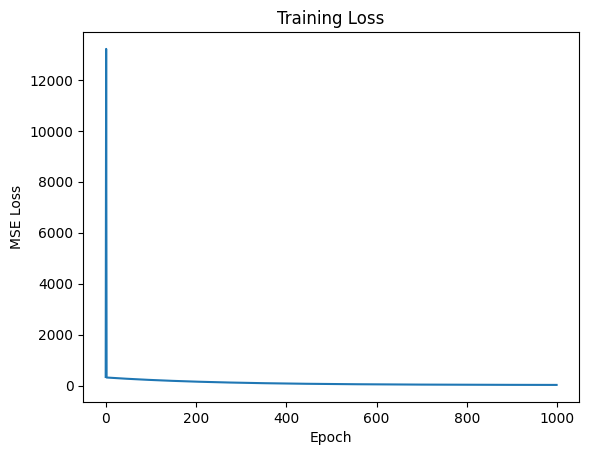

In [19]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.show()

The plot above, illustrates the Mean Squared Error (MSE) loss of the model over 1000 epochs. The x-axis represents the training `Epochs`, and the y-axis represents the `MSE Loss`. As you can observe, the loss significantly decreases in the initial epochs and then gradually stabilizes at a lower value. This decreasing trend indicates that the model is successfully learning from the data and improving its predictive accuracy over time, effectively minimizing the error between its predictions and the actual target values.

## Overall Conclusion

This notebook successfully demonstrates the process of training a linear regression model using PyTorch, adhering to the specified parameters:

*   **Data Generation:** A custom synthetic dataset with 3 features and 1 target was created.
*   **Model Architecture:** A `RegressionModel` was defined with two fully connected layers (an input layer to 16 hidden units with ReLU activation, and a hidden layer to a single output).
*   **Loss Function:** Mean Squared Error (MSE) was used as the criterion.
*   **Optimizer:** Stochastic Gradient Descent (SGD) with a learning rate of 0.001 was employed.
*   **Training:** The model was trained for 1000 epochs with a batch size of 8.

The training loss plot clearly shows the model converging, with the MSE decreasing significantly over the epochs. The printed actual vs. predicted values give an indication of the model's performance on the training data. This workflow effectively accomplishes the task of building and training a linear regression model in PyTorch.